# Census Income Dataset: Exploratory Data Analysis

The goal here is to understand who is in this dataset before touching any model.
The client wants to identify people earning under $50K vs over $50K for marketing.
I want to get a clear picture of the data quality, distributions, and which features
actually seem useful before making any modeling decisions.

What I'm looking at in this notebook:
1. Shape and structure of the data
2. Missing values and how bad they are
3. The target variable and class balance
4. How each key feature relates to income
5. Anything interesting worth flagging for the report

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# keeping plots clean and consistent throughout
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

print('all good')

all good


## 2. Load the Data

The data file has no header row so I need to load column names separately from the .columns file.
Both files are comma separated, just need to combine them properly.

In [2]:
DATA_PATH    = '../data/census-bureau.data'
COLUMNS_PATH = '../data/census-bureau.columns'
PLOTS_PATH   = '../plots/'

# reading column names from the separate file, one name per line
with open(COLUMNS_PATH, 'r') as f:
    columns = [line.strip() for line in f if line.strip()]

print(f'columns found: {len(columns)}')
print(columns)

columns found: 42
['age', 'class of worker', 'detailed industry recode', 'detailed occupation recode', 'education', 'wage per hour', 'enroll in edu inst last wk', 'marital stat', 'major industry code', 'major occupation code', 'race', 'hispanic origin', 'sex', 'member of a labor union', 'reason for unemployment', 'full or part time employment stat', 'capital gains', 'capital losses', 'dividends from stocks', 'tax filer stat', 'region of previous residence', 'state of previous residence', 'detailed household and family stat', 'detailed household summary in household', 'weight', 'migration code-change in msa', 'migration code-change in reg', 'migration code-move within reg', 'live in this house 1 year ago', 'migration prev res in sunbelt', 'num persons worked for employer', 'family members under 18', 'country of birth father', 'country of birth mother', 'country of birth self', 'citizenship', 'own business or self employed', "fill inc questionnaire for veteran's admin", 'veterans benefit

In [3]:
# header=None because there's no header in the data file
# passing our column names directly
df = pd.read_csv(DATA_PATH, header=None, names=columns)

print(f'shape: {df.shape}')
print(f'rows: {df.shape[0]:,}  |  columns: {df.shape[1]}')

shape: (199523, 42)
rows: 199,523  |  columns: 42


In [4]:
# quick look at raw values before touching anything
df.head(3)

,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,...,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.


## 3. Basic Overview

In [5]:
# checking what types pandas inferred
# expecting a mix of numeric and object (text) columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199523 entries, 0 to 199522
Data columns (total 42 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   age                                         199523 non-null  int64  
 1   class of worker                             199523 non-null  object 
 2   detailed industry recode                    199523 non-null  int64  
 3   detailed occupation recode                  199523 non-null  int64  
 4   education                                   199523 non-null  object 
 5   wage per hour                               199523 non-null  int64  
 6   enroll in edu inst last wk                  199523 non-null  object 
 7   marital stat                                199523 non-null  object 
 8   major industry code                         199523 non-null  object 
 9   major occupation code                       199523 non-null  object 
 

In [6]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
df.describe(include='all').round(2)

,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,race,hispanic origin,sex,member of a labor union,reason for unemployment,full or part time employment stat,capital gains,capital losses,dividends from stocks,tax filer stat,region of previous residence,state of previous residence,detailed household and family stat,detailed household summary in household,weight,migration code-change in msa,migration code-change in reg,migration code-move within reg,live in this house 1 year ago,migration prev res in sunbelt,num persons worked for employer,family members under 18,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
count,199523.00,199523,199523.00,199523.00,199523,199523.00,199523,199523,199523,199523,199523,198649,199523,199523,199523,199523,199523.00,199523.00,199523.00,199523,199523,199523,199523,199523,199523.00,199523,199523,199523,199523,199523,199523.00,199523,199523,199523,199523,199523,199523.00,199523,199523.00,199523.00,199523.0,199523
unique,NaN,9,NaN,NaN,17,NaN,3,7,24,15,5,9,2,3,6,8,NaN,NaN,NaN,6,6,51,38,8,NaN,10,9,10,3,4,NaN,5,43,43,43,5,NaN,3,NaN,NaN,NaN,2
top,NaN,Not in universe,NaN,NaN,High school graduate,NaN,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,NaN,NaN,NaN,Nonfiler,Not in universe,Not in universe,Householder,Householder,NaN,?,?,?,Not in universe under 1 year old,?,NaN,Not in universe,United-States,United-States,United-States,Native- Born in the United States,NaN,Not in universe,NaN,NaN,NaN,- 50000.
freq,NaN,100245,NaN,NaN,48407,NaN,186943,86485,100684,100684,167365,171907,103984,180459,193453,123769,NaN,NaN,NaN,75094,183750,183750,53248,75475,NaN,99696,99696,99696,101212,99696,NaN,144232,159163,160479,176989,176992,NaN,197539,NaN,NaN,NaN,187141
mean,34.49,NaN,15.35,11.31,NaN,55.43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,434.72,37.31,197.53,NaN,NaN,NaN,NaN,NaN,1740.38,NaN,NaN,NaN,NaN,NaN,1.96,NaN,NaN,NaN,NaN,NaN,0.18,NaN,1.51,23.17,94.5,NaN
std,22.31,NaN,18.07,14.45,NaN,274.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4697.53,271.90,1984.16,NaN,NaN,NaN,NaN,NaN,993.77,NaN,NaN,NaN,NaN,NaN,2.37,NaN,NaN,NaN,NaN,NaN,0.55,NaN,0.85,24.41,0.5,NaN
min,0.00,NaN,0.00,0.00,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,37.87,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,0.00,NaN,0.00,0.00,94.0,NaN
25%,15.00,NaN,0.00,0.00,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,1061.62,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,0.00,NaN,2.00,0.00,94.0,NaN
50%,33.00,NaN,0.00,0.00,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,1618.31,NaN,NaN,NaN,NaN,NaN,1.00,NaN,NaN,NaN,NaN,NaN,0.00,NaN,2.00,8.00,94.0,NaN
75%,50.00,NaN,33.00,26.00,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,2188.61,NaN,NaN,NaN,NaN,NaN,4.00,NaN,NaN,NaN,NaN,NaN,0.00,NaN,2.00,52.00,95.0,NaN


In [7]:
# splitting into numeric vs categorical so I can analyze them separately
numeric_cols     = df.select_dtypes(include='number').columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print(f'numeric columns ({len(numeric_cols)}):')
print(numeric_cols)
print(f'\ncategorical columns ({len(categorical_cols)}):')
print(categorical_cols)

numeric columns (13):
['age', 'detailed industry recode', 'detailed occupation recode', 'wage per hour', 'capital gains', 'capital losses', 'dividends from stocks', 'weight', 'num persons worked for employer', 'own business or self employed', 'veterans benefits', 'weeks worked in year', 'year']

categorical columns (29):
['class of worker', 'education', 'enroll in edu inst last wk', 'marital stat', 'major industry code', 'major occupation code', 'race', 'hispanic origin', 'sex', 'member of a labor union', 'reason for unemployment', 'full or part time employment stat', 'tax filer stat', 'region of previous residence', 'state of previous residence', 'detailed household and family stat', 'detailed household summary in household', 'migration code-change in msa', 'migration code-change in reg', 'migration code-move within reg', 'live in this house 1 year ago', 'migration prev res in sunbelt', 'family members under 18', 'country of birth father', 'country of birth mother', 'country of birth 

In [8]:
# basic stats for numeric columns
# looking for anything weird like negative ages or crazy outliers
df[numeric_cols].describe().round(2)

,age,detailed industry recode,detailed occupation recode,wage per hour,capital gains,capital losses,dividends from stocks,weight,num persons worked for employer,own business or self employed,veterans benefits,weeks worked in year,year
count,199523.00,199523.00,199523.00,199523.00,199523.00,199523.00,199523.00,199523.00,199523.00,199523.00,199523.00,199523.00,199523.0
mean,34.49,15.35,11.31,55.43,434.72,37.31,197.53,1740.38,1.96,0.18,1.51,23.17,94.5
std,22.31,18.07,14.45,274.90,4697.53,271.90,1984.16,993.77,2.37,0.55,0.85,24.41,0.5
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,37.87,0.00,0.00,0.00,0.00,94.0
25%,15.00,0.00,0.00,0.00,0.00,0.00,0.00,1061.62,0.00,0.00,2.00,0.00,94.0
50%,33.00,0.00,0.00,0.00,0.00,0.00,0.00,1618.31,1.00,0.00,2.00,8.00,94.0
75%,50.00,33.00,26.00,0.00,0.00,0.00,0.00,2188.61,4.00,0.00,2.00,52.00,95.0
max,90.00,51.00,46.00,9999.00,99999.00,4608.00,99999.00,18656.30,6.00,2.00,2.00,52.00,95.0


## 4. Clean the Target Variable

The label column has leading spaces in the raw values so need to strip those first.
Then mapping to binary: 0 = under $50K, 1 = over $50K.

In [9]:
# checking raw values first before cleaning
print('raw label values:')
print(df['label'].value_counts())

raw label values:
label
- 50000.    187141
50000+.      12382
Name: count, dtype: int64


In [10]:
# stripping whitespace then converting to 0/1
df['label'] = df['label'].str.strip()
df['label'] = df['label'].map({'- 50000.': 0, '50000+.': 1})

print('cleaned label distribution:')
print(df['label'].value_counts())
print('\nclass balance:')
print(df['label'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

cleaned label distribution:
label
0    187141
1     12382
Name: count, dtype: int64

class balance:
label
0    93.79%
1     6.21%
Name: proportion, dtype: object


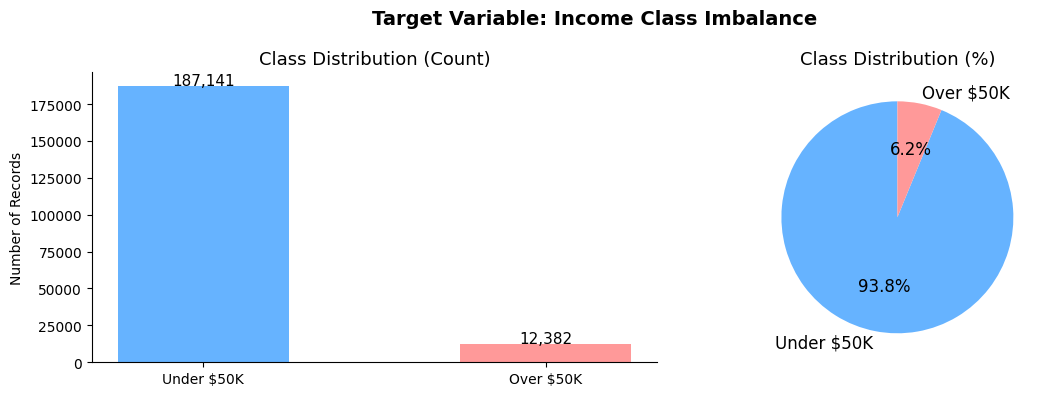


class imbalance is significant: ~94% under $50K vs ~6% over $50K
will need to handle this during modeling, cannot rely on accuracy as a metric


In [11]:
# visualizing the imbalance, this is really important for the modeling decisions later
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['label'].value_counts()
labels_text = ['Under $50K', 'Over $50K']
colors = ['#66b3ff', '#ff9999']

axes[0].bar(labels_text, counts.values, color=colors, width=0.5)
axes[0].set_title('Class Distribution (Count)', fontsize=13)
axes[0].set_ylabel('Number of Records')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=11)

axes[1].pie(counts.values, labels=labels_text, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Class Distribution (%)', fontsize=13)

plt.suptitle('Target Variable: Income Class Imbalance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_PATH + 'plot_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

# ~94% earn under 50k which means accuracy is a useless metric here
# a model that just predicts 0 every time would score 94% accuracy
# I'll use AUC-ROC and F1 instead throughout this project
print('\nclass imbalance is significant: ~94% under $50K vs ~6% over $50K')
print('will need to handle this during modeling, cannot rely on accuracy as a metric')

## 5. Missing Values

Missing values in this dataset show up as ' ?' (space + question mark), not as empty cells.
Need to replace those with NaN so pandas treats them as missing properly.

In [12]:
# replacing both ' ?' and '?' just to be safe
df.replace(' ?', np.nan, inplace=True)
df.replace('?', np.nan, inplace=True)

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(f'columns with missing values: {len(missing_df)}')
missing_df

columns with missing values: 9


,Missing Count,Missing %
migration code-change in msa,99696,49.97
migration code-change in reg,99696,49.97
migration code-move within reg,99696,49.97
migration prev res in sunbelt,99696,49.97
country of birth father,6713,3.36
country of birth mother,6119,3.07
country of birth self,3393,1.70
hispanic origin,874,0.44
state of previous residence,708,0.35


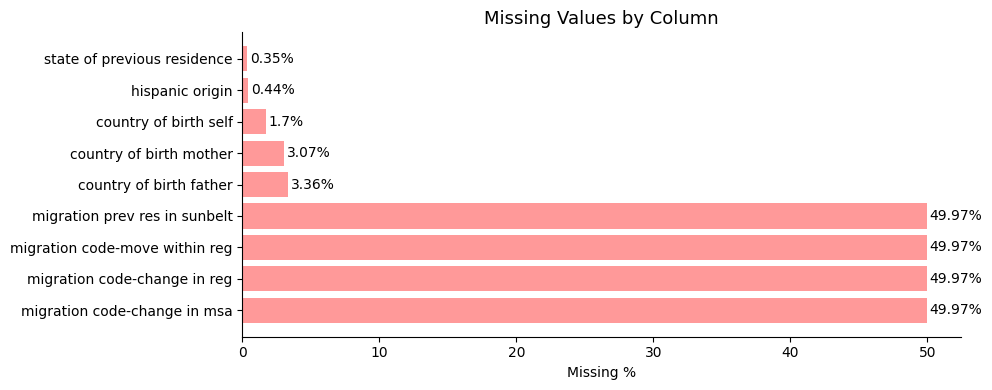

In [13]:
if len(missing_df) > 0:
    plt.figure(figsize=(10, 4))
    plt.barh(missing_df.index, missing_df['Missing %'], color='#ff9999')
    plt.xlabel('Missing %')
    plt.title('Missing Values by Column', fontsize=13)
    for i, v in enumerate(missing_df['Missing %']):
        plt.text(v + 0.2, i, f'{v}%', va='center')
    plt.tight_layout()
    plt.savefig(PLOTS_PATH + 'plot_missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('no missing values found')

## 6. The Weight Column

This one is easy to miss but important. The weight column is not a feature.
It tells us how many real people each row represents in the actual population.
The census used stratified sampling so some groups were over or under sampled.
I'll exclude it from the model but use it here to get population-level numbers.

In [14]:
print('weight column stats:')
print(df['weight'].describe().round(2))

print(f'\ntotal population this dataset represents: {df["weight"].sum():,.0f}')

# weighted breakdown gives a more accurate real-world picture than raw counts
weighted_over50  = df[df['label'] == 1]['weight'].sum()
weighted_under50 = df[df['label'] == 0]['weight'].sum()
total_weight     = df['weight'].sum()

print(f'\npopulation-weighted income split:')
print(f'  under $50K: {weighted_under50/total_weight*100:.1f}%')
print(f'  over $50K:  {weighted_over50/total_weight*100:.1f}%')
print('\nwill drop weight before training, it is not a real feature')

weight column stats:
count    199523.00
mean       1740.38
std         993.77
min          37.87
25%        1061.62
50%        1618.31
75%        2188.61
max       18656.30
Name: weight, dtype: float64

total population this dataset represents: 347,245,892

population-weighted income split:
  under $50K: 93.6%
  over $50K:  6.4%

will drop weight before training, it is not a real feature


## 7. Numeric Features

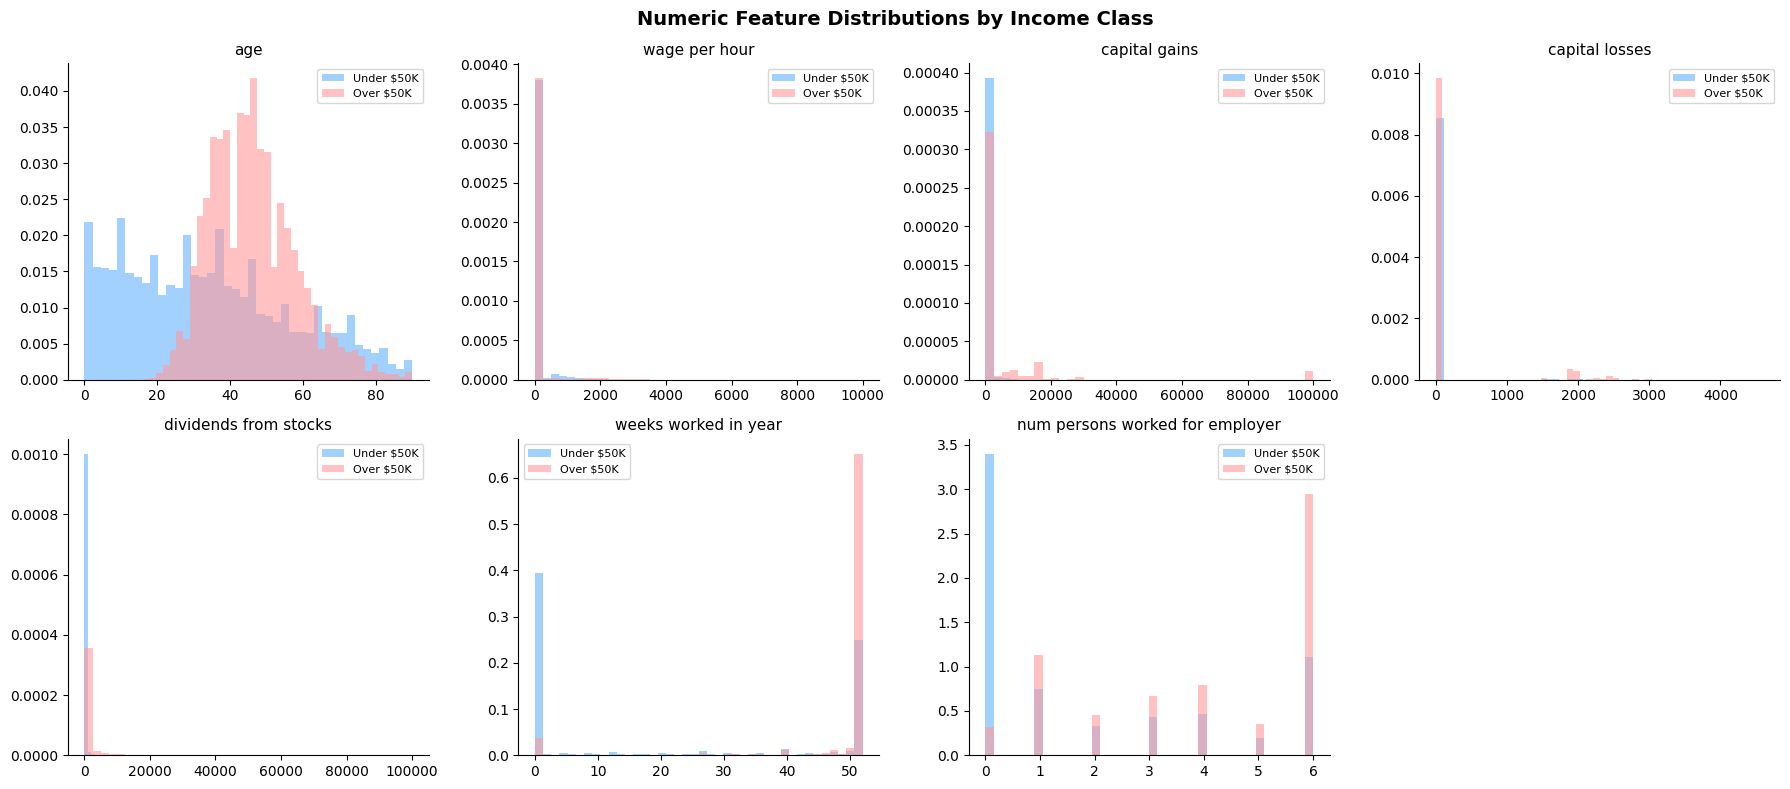

In [15]:
# focusing on the meaningful numeric features
# leaving out weight, year, and the recode columns since those are more categorical in nature
key_numeric = ['age', 'wage per hour', 'capital gains', 'capital losses',
               'dividends from stocks', 'weeks worked in year',
               'num persons worked for employer']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(key_numeric):
    under = df[df['label'] == 0][col].dropna()
    over  = df[df['label'] == 1][col].dropna()
    axes[i].hist(under, bins=40, alpha=0.6, label='Under $50K', color='#66b3ff', density=True)
    axes[i].hist(over,  bins=40, alpha=0.6, label='Over $50K',  color='#ff9999', density=True)
    axes[i].set_title(col, fontsize=11)
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)

plt.suptitle('Numeric Feature Distributions by Income Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_PATH + 'plot_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

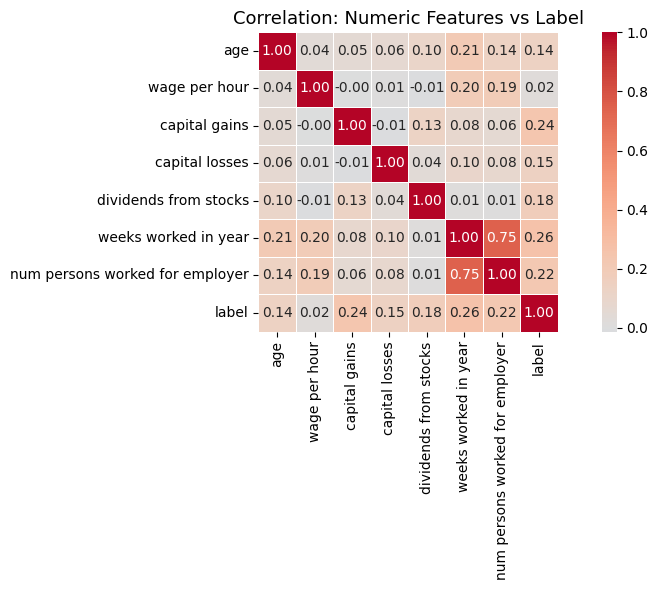


features ranked by correlation with income:
weeks worked in year               0.262
capital gains                      0.241
num persons worked for employer    0.223
dividends from stocks              0.176
capital losses                     0.147
age                                0.136
wage per hour                      0.025
Name: label, dtype: float64


In [16]:
# correlation heatmap to see which numeric features are most related to the label
plt.figure(figsize=(10, 6))
corr = df[key_numeric + ['label']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Correlation: Numeric Features vs Label', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS_PATH + 'plot_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nfeatures ranked by correlation with income:')
print(corr['label'].drop('label').sort_values(ascending=False).round(3))

## 8. Categorical Features

In [17]:
# stripping whitespace from all categorical columns first
# the raw data has leading spaces in a lot of string values
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

key_categorical = ['education', 'sex', 'race', 'marital stat',
                   'class of worker', 'major occupation code', 'major industry code']

print('unique values per categorical column:')
for col in key_categorical:
    print(f'  {col}: {df[col].nunique()} unique values')

unique values per categorical column:
  education: 17 unique values
  sex: 2 unique values
  race: 5 unique values
  marital stat: 7 unique values
  class of worker: 9 unique values
  major occupation code: 15 unique values
  major industry code: 24 unique values


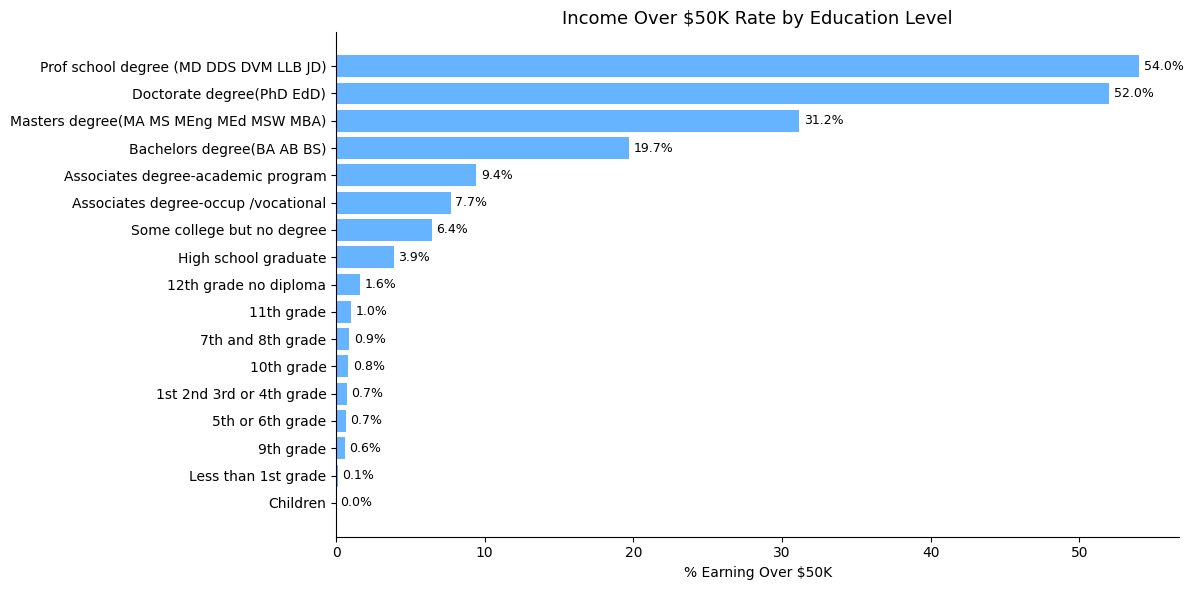

In [18]:
# education is probably the most intuitive one to look at first
# expecting a clear pattern where higher education = more likely to earn over 50k
edu_income = df.groupby('education')['label'].mean().sort_values(ascending=True) * 100

plt.figure(figsize=(12, 6))
bars = plt.barh(edu_income.index, edu_income.values, color='#66b3ff')
plt.xlabel('% Earning Over $50K')
plt.title('Income Over $50K Rate by Education Level', fontsize=13)
for bar, val in zip(bars, edu_income.values):
    plt.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(PLOTS_PATH + 'plot_income_by_education.png', dpi=150, bbox_inches='tight')
plt.show()

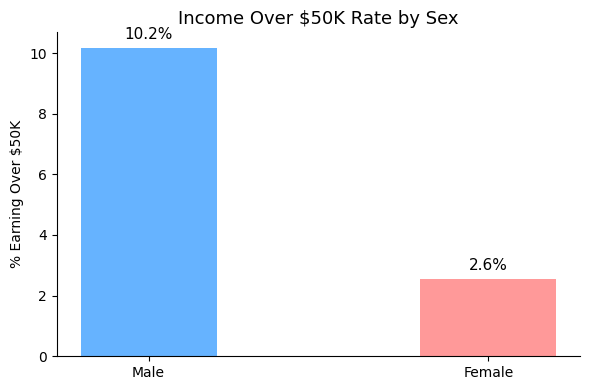

In [19]:
# looking at the income gap by sex
sex_income = df.groupby('sex')['label'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(6, 4))
plt.bar(sex_income.index, sex_income.values, color=['#66b3ff', '#ff9999'], width=0.4)
plt.ylabel('% Earning Over $50K')
plt.title('Income Over $50K Rate by Sex', fontsize=13)
for i, (idx, val) in enumerate(sex_income.items()):
    plt.text(i, val + 0.3, f'{val:.1f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig(PLOTS_PATH + 'plot_income_by_sex.png', dpi=150, bbox_inches='tight')
plt.show()

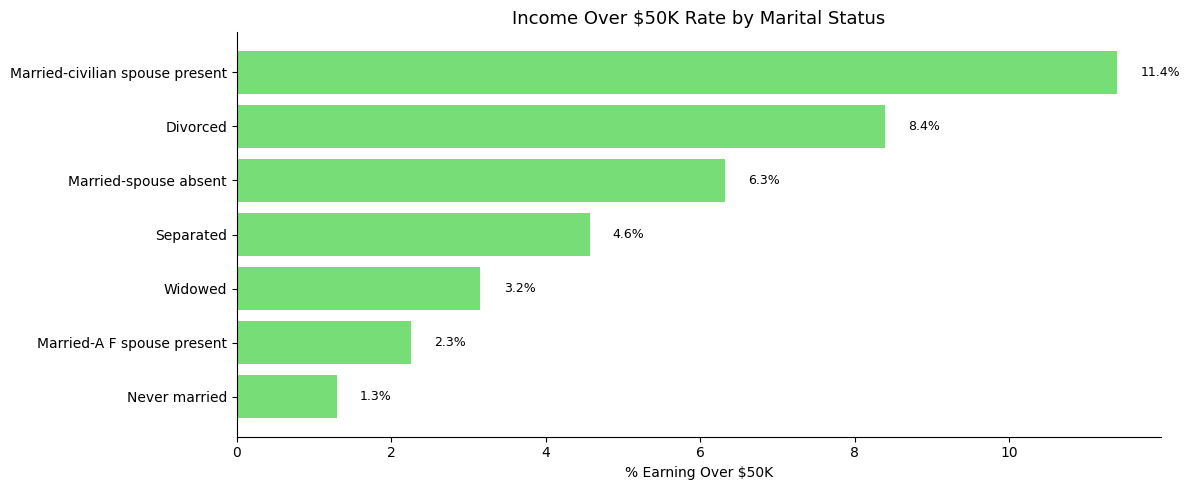

In [20]:
# marital status is interesting because it captures household context
# married people often have dual incomes or more financial stability
marital_income = df.groupby('marital stat')['label'].mean().sort_values(ascending=True) * 100

plt.figure(figsize=(12, 5))
bars = plt.barh(marital_income.index, marital_income.values, color='#77dd77')
plt.xlabel('% Earning Over $50K')
plt.title('Income Over $50K Rate by Marital Status', fontsize=13)
for bar, val in zip(bars, marital_income.values):
    plt.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(PLOTS_PATH + 'plot_income_by_marital.png', dpi=150, bbox_inches='tight')
plt.show()

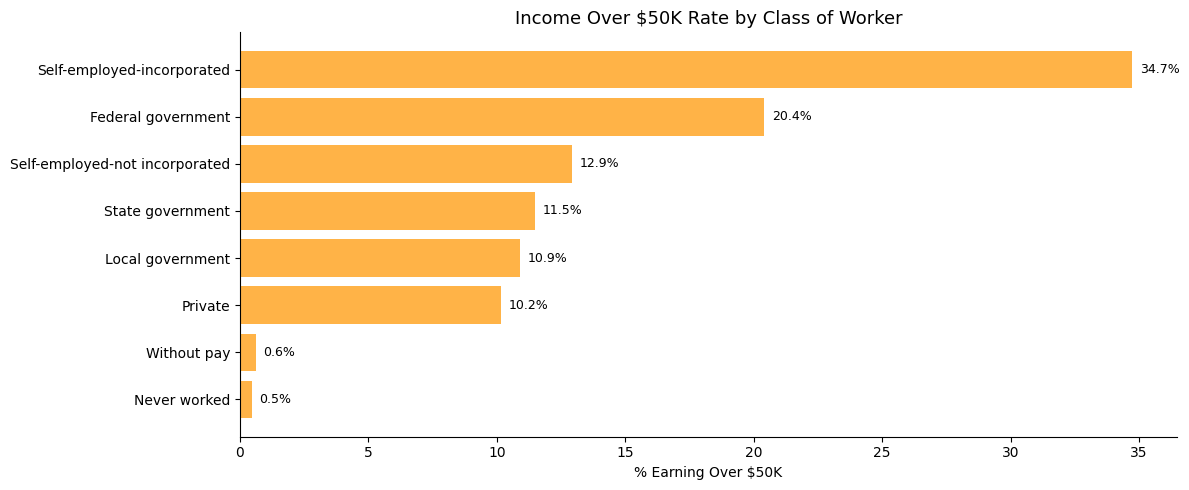

In [21]:
# class of worker tells us a lot about earning potential
# removing 'Not in universe' since those are people outside the labor force
worker_income = df.groupby('class of worker')['label'].mean().sort_values(ascending=True) * 100
worker_income = worker_income[worker_income.index != 'Not in universe']

plt.figure(figsize=(12, 5))
bars = plt.barh(worker_income.index, worker_income.values, color='#ffb347')
plt.xlabel('% Earning Over $50K')
plt.title('Income Over $50K Rate by Class of Worker', fontsize=13)
for bar, val in zip(bars, worker_income.values):
    plt.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(PLOTS_PATH + 'plot_income_by_worker_class.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Age Analysis

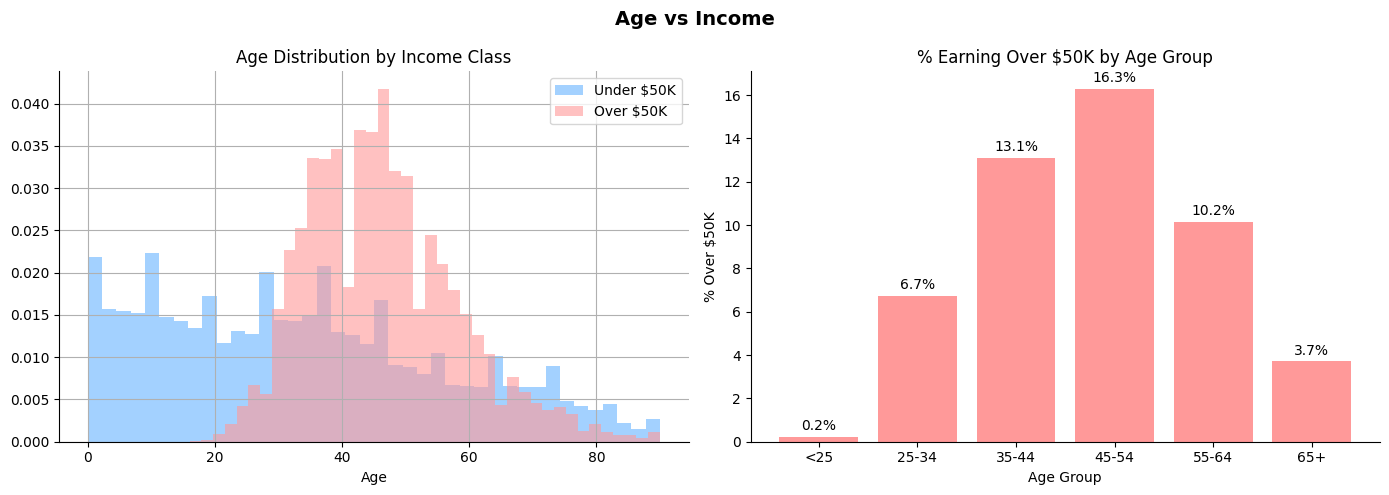

In [22]:
# age is usually one of the strongest predictors in income data
# people in their 40s and 50s tend to be at peak earnings
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[df['label'] == 0]['age'].hist(bins=40, alpha=0.6, label='Under $50K',
                                  color='#66b3ff', ax=axes[0], density=True)
df[df['label'] == 1]['age'].hist(bins=40, alpha=0.6, label='Over $50K',
                                  color='#ff9999', ax=axes[0], density=True)
axes[0].set_title('Age Distribution by Income Class', fontsize=12)
axes[0].set_xlabel('Age')
axes[0].legend()

df['age_group'] = pd.cut(df['age'], bins=[0,25,35,45,55,65,100],
                          labels=['<25','25-34','35-44','45-54','55-64','65+'])
age_income = df.groupby('age_group', observed=True)['label'].mean() * 100

axes[1].bar(age_income.index.astype(str), age_income.values, color='#ff9999')
axes[1].set_title('% Earning Over $50K by Age Group', fontsize=12)
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('% Over $50K')
for i, v in enumerate(age_income.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)

plt.suptitle('Age vs Income', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_PATH + 'plot_age_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# dropping the temp column I just made
df.drop(columns=['age_group'], inplace=True)

## 10. Capital Gains and Dividends

In [23]:
# most people have zero capital gains or dividends
# but the ones who do are much more likely to be high earners
# this makes sense as investment income is a sign of wealth

print('people with any capital gains:')
print(f'  under $50K earners: {(df[df["label"]==0]["capital gains"]>0).mean()*100:.1f}%')
print(f'  over  $50K earners: {(df[df["label"]==1]["capital gains"]>0).mean()*100:.1f}%')

print('\npeople with any dividend income:')
print(f'  under $50K earners: {(df[df["label"]==0]["dividends from stocks"]>0).mean()*100:.1f}%')
print(f'  over  $50K earners: {(df[df["label"]==1]["dividends from stocks"]>0).mean()*100:.1f}%')

print('\nhaving any investment income is a strong signal for high earner status')
print('this will likely be an important feature in the model')

people with any capital gains:
  under $50K earners: 2.7%
  over  $50K earners: 19.5%

people with any dividend income:
  under $50K earners: 8.5%
  over  $50K earners: 42.9%

having any investment income is a strong signal for high earner status
this will likely be an important feature in the model


## 11. Feature Grouping

Grouping all 40 features into business-meaningful categories.
This helps when explaining the model to the client and when deciding
which feature groups matter most for income prediction.

In [24]:
feature_groups = {
    'Demographics': [
        'age', 'sex', 'race', 'hispanic origin', 'citizenship',
        'country of birth self', 'country of birth father', 'country of birth mother'
    ],
    'Employment': [
        'class of worker', 'major occupation code', 'major industry code',
        'detailed occupation recode', 'detailed industry recode',
        'full or part time employment stat', 'weeks worked in year',
        'wage per hour', 'num persons worked for employer',
        'own business or self employed', 'member of a labor union',
        'reason for unemployment'
    ],
    'Education': [
        'education', 'enroll in edu inst last wk'
    ],
    'Financial': [
        'capital gains', 'capital losses', 'dividends from stocks',
        'tax filer stat'
    ],
    'Household and Family': [
        'marital stat', 'family members under 18',
        'detailed household and family stat',
        'detailed household summary in household'
    ],
    'Geographic and Migration': [
        'region of previous residence', 'state of previous residence',
        'migration code-change in msa', 'migration code-change in reg',
        'migration code-move within reg', 'live in this house 1 year ago',
        'migration prev res in sunbelt'
    ],
    'Veterans': [
        "fill inc questionnaire for veteran's admin", 'veterans benefits'
    ],
    'Exclude from model': [
        'weight', 'year'
    ]
}

for group, features in feature_groups.items():
    print(f'[{group}] ({len(features)} features)')
    print(f'  {features}\n')

[Demographics] (8 features)
  ['age', 'sex', 'race', 'hispanic origin', 'citizenship', 'country of birth self', 'country of birth father', 'country of birth mother']

[Employment] (12 features)
  ['class of worker', 'major occupation code', 'major industry code', 'detailed occupation recode', 'detailed industry recode', 'full or part time employment stat', 'weeks worked in year', 'wage per hour', 'num persons worked for employer', 'own business or self employed', 'member of a labor union', 'reason for unemployment']

[Education] (2 features)
  ['education', 'enroll in edu inst last wk']

[Financial] (4 features)
  ['capital gains', 'capital losses', 'dividends from stocks', 'tax filer stat']

[Household and Family] (4 features)
  ['marital stat', 'family members under 18', 'detailed household and family stat', 'detailed household summary in household']

[Geographic and Migration] (7 features)
  ['region of previous residence', 'state of previous residence', 'migration code-change in ms

## 12. Save Cleaned Data

In [25]:
# saving the cleaned version to use in the next notebook
# at this point: whitespace stripped, label encoded to 0/1, NaN replacing ?
df.to_csv('../data/census_cleaned.csv', index=False)
print(f'saved to: data/census_cleaned.csv')
print(f'shape: {df.shape}')
print('\nready for notebook 02: preprocessing and classification')

saved to: data/census_cleaned.csv
shape: (199523, 42)

ready for notebook 02: preprocessing and classification


## EDA Summary

Key findings from this analysis:

| Finding | What it means for the model |
|---|---|
| 94% earn under $50K | Heavy class imbalance, cannot use accuracy as a metric |
| Education strongly predicts income | Degree holders are much more likely to earn over $50K |
| Age 35 to 54 are peak earners | Mid-career professionals are the main high-income segment |
| Capital gains and dividends are strong signals | Even having a small amount is a good predictor |
| Married people earn more on average | Marital status interacts with income in an interesting way |
| Weight column is not a feature | It represents population sampling, will be excluded from model |
| Migration columns have most missing values | Will decide on dropping or imputing in next notebook |